In [1]:
%load_ext autoreload
%autoreload 2

## Fraud_Data Detection Model Shap Analysis - using the chosen best model - LightGBM


In [2]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from src.preprocessing import FraudDetectionPipeline

2026-06-15 00:32:43,814 - INFO - Processed data loaded: (151112, 12)
2026-06-15 00:32:43,947 - INFO - Ran Feature Engineering.......
2026-06-15 00:32:44,336 - INFO - Computing transaction_frequency (train only)...
2026-06-15 00:32:44,869 - INFO - Applying Target Encoding to 'country'...
2026-06-15 00:32:45,304 - WARNING - Skipping scaling for zero-variance columns (will keep raw values): ['transaction_frequency']
2026-06-15 00:32:45,472 - INFO - Standard Scaling done....
2026-06-15 00:32:45,930 - INFO - One-Hot Encoding applied to 3 columns: ['source', 'browser', 'sex']
2026-06-15 00:32:45,957 - INFO - Categorical features detected → Using SMOTENC


Training shape before SMOTE: (120889, 18)
Training shape after  SMOTE: (164352, 18)


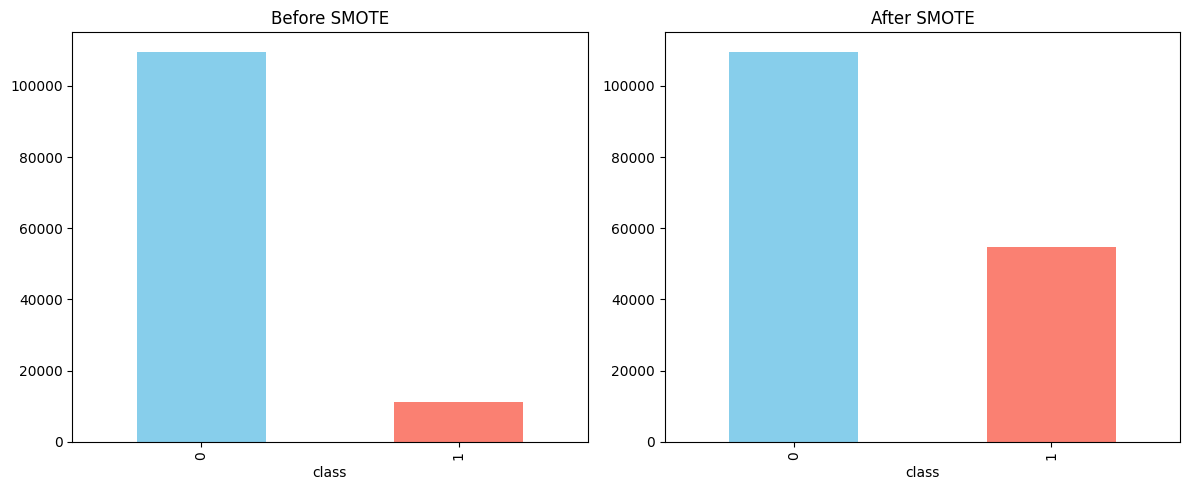

In [4]:
frauddata_preprocessing=FraudDetectionPipeline('../data/processed/processedData.csv', is_fraud=True)
X_train, y_train, X_test, y_test=frauddata_preprocessing.run()

#### Load the saved model

In [5]:
fraud_model = joblib.load("../models/fraud/LightGBM_final_model_target.pkl")

In [6]:
model_expected_features = fraud_model.n_features_in_
current_data_features = X_test.shape[1]

print(f"Model expects: {model_expected_features} features")
print(f"X_test has: {current_data_features} features")


if model_expected_features == current_data_features:
    model_names = set(fraud_model.feature_names_in_)
    data_names = set(X_test.columns)
    print("Missing from data:", model_names - data_names)
    print("Extra in data:", data_names - model_names)


Model expects: 18 features
X_test has: 18 features
Missing from data: set()
Extra in data: set()


In [7]:
explainer = shap.TreeExplainer(fraud_model)
shap_values = explainer(X_test)

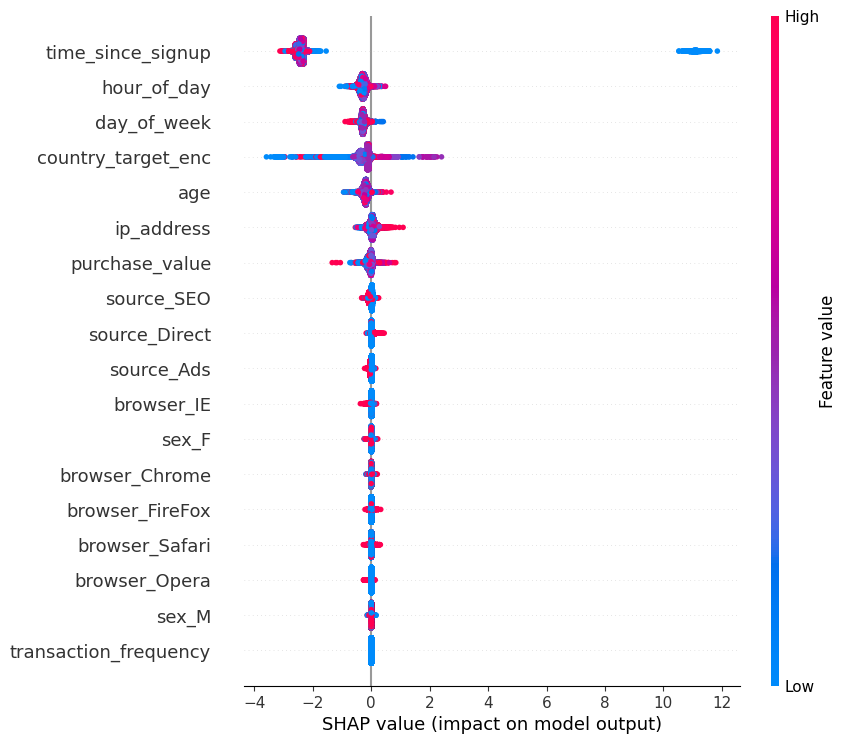

In [8]:
plt.figure(figsize=(10, 10))
shap.plots.beeswarm(shap_values, max_display=18)
plt.show()

In [9]:
preds = fraud_model.predict(X_test)

true_positives = np.where((preds == 1) & (y_test == 1))[0]
false_positives = np.where((preds == 1) & (y_test == 0))[0]
false_negatives = np.where((preds == 0) & (y_test == 1))[0]

print(f"True Positive row indices available: {true_positives[:5]}")
print(f"False Positive row indices available: {false_positives[:5]}")
print(f"False Negative row indices available: {false_negatives[:5]}")

True Positive row indices available: [17 24 25 58 74]
False Positive row indices available: [11383 26212 26637]
False Negative row indices available: [  2  29  46  56 100]


In [10]:

shap.initjs()

tp_idx = true_positives[0]
fp_idx = false_positives[0]
fn_idx = false_negatives[0]

print(f"--- Force Plot for True Positive (Row {tp_idx}) ---")
shap.plots.force(shap_values[tp_idx])

print(f"--- Force Plot for False Positive (Row {fp_idx}) ---")
shap.plots.force(shap_values[fp_idx])

print(f"--- Force Plot for False Negative (Row {fn_idx}) ---")
shap.plots.force(shap_values[fn_idx])

--- Force Plot for True Positive (Row 17) ---
--- Force Plot for False Positive (Row 11383) ---
--- Force Plot for False Negative (Row 2) ---


#### Fraud_Data Fraud model Shap Analysis and Business Recommendation



##### 1. SHAP Interpretations

 Plot 1: SHAP Summary Plot (Global Feature Importance & Effects)

This plot reveals the overarching rules the LightGBM model learned across the entire dataset, ranked from most important (top) to least important (bottom).

* `time_since_signup` (The Ultimate Predictor): This is by far the most dominant feature.
* Low values (blue dots) have massive positive SHAP values (up to +12): When a user transacts almost immediately after creating an account, the risk score skyrockets.
* High values (red dots) have negative SHAP values (~ -3): Accounts that have matured over time are strongly trusted by the model and pull down the risk score.


* `hour_of_day` & `day_of_week`: These display tight, localized variance around the center, but extreme high or low values (outliers) swing the risk score by $\pm 1$. This implies specific hours (e.g., late-night spikes) or weekends introduce conditional fraud risks.
* `country_target_enc`: Low target encoded values (blue) significantly lower the risk score, while certain encoded regions (red) stretch into the positive SHAP territory, indicating localized fraud rings or high-risk geographic corridors.
* `age` & `ip_address` & `purchase_value`: These serve as secondary behavioral signals. For instance, specific high/low values in `purchase_value` trigger minor localized risk shifts, though they are vastly secondary to account age.

 Plot 2: SHAP Force Plot (Individual Low-Risk Transaction Case Study)

The force plot shows an individual prediction where the model output is $f(x) = -3.21$. Given that the base value is $0.5313$, this transaction was pushed heavily into the "Not Fraud" category.

* Why the model approved this transaction: * `time_since_signup = 0.8197` and `age = -1.412` are the primary drivers (represented by the long blue blocks pushing the score to the left). The account has sufficient tenure relative to the action, acting as a powerful trust signal.
* `hour_of_day = 1.226`, `day_of_week = -1.503`, and `country_target_enc = -0.3727` also act as smaller trust factors, moving the prediction further left.


* The opposing force: `ip_address = 1.415` (pink block) tries to push the risk score higher, but its impact is completely overwhelmed by the collective weight of the trust signals.


##### 2. Business Implications

 The Fraud Phenomenon

The fraud landscape is heavily defined by velocity and account age. Fraudsters are generating new accounts and immediately attempting transactions before security layers can flag them. Mature accounts, on the other hand, show remarkably steady, organic behavior.

 Why LightGBM's Precision is Near-Perfect

Because the SHAP values for `time_since_signup` explode so violently into positive territory (SHAP $> 10$), LightGBM has found a binary distinction for a subset of hyper-fraudulent activity.  This explains how the model achieved 1.00 Precision and only 2 False Positives out of 30,000+ test samples.

 The Hidden Risk: The 48% Missed Fraud (False Negatives)

While a precision of 1.00 is an operational dream (zero false alarms), The model has a 0.5240 Recall. This means 1,347 actual frauds sneaked past LightGBM.
Looking at the SHAP summary plot, features like `purchase_value`, `source_Ads/SEO`, and `browser_Chrome/Safari` are tightly clustered around zero. This means sophisticated fraudsters using aged accounts, normal purchase amounts, and standard web browsers completely bypass the primary detection rules.



##### 3. Business Recommendations

 Short-Term: Optimize the Funnel for New Accounts

1. Implement Dynamic KYC / Step-Up Authentication: Do not block new accounts entirely, but use the `time_since_signup` signal to trigger frictionless friction. If a user tries to purchase something within $X$ minutes of signing up, automatically force Multi-Factor Authentication (MFA), ID verification, or a biometric check.
2. Instant Operational Savings: Since the model has a near-perfect precision (1.00), the model can fully automate the rejection of transactions flagged as high-risk by LightGBM. A safety check team will review exactly 2 false positives, saving thousands of hours in manual review overhead.

 Medium-Term: Catch the 48% Stealth Fraud

Because LightGBM is over-indexed on account age, it is blind to account takeover (ATO) fraud or patient fraudsters who let accounts age before striking.

1. Engineered Behavior Features: Introduce features that look at deviations from a user's normal baseline rather than static variables. Examples include:
* `device_velocity`: Has this mature account changed devices 3 times today?
* `distance_from_home`: Is the transaction IP drastically different from the signup IP?
* `transaction_frequency_spike`: A sudden jump in purchase volume relative to historical averages.


2. Adjust the Threshold for the Balanced Tier: LightGBM's current default threshold prioritizes precision. Consider creating a multi-tiered routing strategy:
* Score > 0.8: Instant Block (High Precision bucket).
* Score 0.4 to 0.8: Route to Manual Review or Step-Up Authentication (To catch the missing 1,347 fraud cases).
* Score < 0.4: Auto-Approve.



##### Glossary 

 **Business & Operational Terms**

* Account Takeover (ATO): A form of identity theft where a malicious third party gains unauthorized access to a legitimate user's mature account, changing details and making fraudulent transactions.

* Friction / Frictionless Friction: "Friction" refers to steps that slow down a user experience (e.g., typing a password, verifying an SMS). "Frictionless friction" or *dynamic friction* means only forcing these annoying steps on high-risk users, leaving legitimate users completely uninterrupted.

* False Negative (Missed Fraud): An actual fraudulent transaction that the model incorrectly guessed was safe, allowing it to go through. Business Impact: Direct financial loss via chargebacks and lost inventory.

* False Positive (False Alarm): A perfectly legitimate transaction made by a real customer that the model flags as fraud. Business Impact: Customer frustration, support tickets, and unnecessary manual review labor.

* Manual Review / Safety Check: The operational process where a specialized team of human fraud analysts manually inspects flagged transactions to decide whether to approve or cancel them.

* Step-Up Authentication / Dynamic KYC: A security trigger that demands extra proof of identity (like a fingerprint scan, facial ID, or uploading a government ID) *only* when a transaction looks suspicious. "KYC" stands for *Know Your Customer*.

* Velocity / Behavior Velocity: The speed or frequency at which a user performs actions (e.g., opening an account and buying an item within 5 seconds, or changing devices multiple times in an hour). Rapid velocity is a major fraud indicator.



 **Technical & Data Science Terms**

* Base Value (Expected Value): The baseline starting score of a SHAP plot. It represents what the model would guess the risk is if it knew absolutely nothing about the specific transaction (the mathematical average of the whole dataset).

* F1-Score: A single metric that scores a model's balance between Precision and Recall. A high F1-score means the model is highly effective at catching fraud without causing an absolute operational disaster of false alarms.

* LightGBM: Short for *Light Gradient Boosting Machine*. An incredibly fast, high-performance machine learning model framework that builds a sequence of decision trees to predict complex outcomes like fraud.

* Outliers: Data points that lie a far distance away from the rest of the dataset (e.g., an exceptionally massive purchase value, or a transaction coming in at 4:00 AM on a Tuesday).

* Precision: The model's accuracy rate when it screams "Fraud!". A precision of 1.00 (100%) means every single transaction the model flags as fraud is actually fraud—zero false alarms.

* Recall: The percentage of total actual fraud that the model successfully catches. A recall of 0.52 (52%) means the model catches a little over half of the bad guys, but misses the other 48%.

* SHAP (SHapley Additive exPlanations): A mathematical framework used to explain the output of complex "black box" machine learning models. It scores exactly how much each feature (like `age` or `ip_address`) pushed a transaction's risk score higher or lower.

* SHAP Force Plot: A visualization showing a single transaction's prediction. It acts like a tug-of-war map, showing which features pushed the risk score up (pink) vs. down (blue).

* SHAP Summary Plot: A global chart showing the entire dataset at once, ranking features from top to bottom by how much power they have over the model's decision-making process.

* Target Encoding (`_target_enc`): A data preprocessing technique that converts categorical words (like country names: "US", "CA") into numbers based on the historical fraud rate of that category.



 Quick-Reference Metric Summary

| Metric Term | What It Asks | Current LightGBM Score | What it Means |
| --- | --- | --- | --- |
| Precision | "When the model blocks a transaction, how often is it right?" | 1.00 (100%) | The blocks are perfectly accurate. No customers are being falsely blocked. |
| Recall | "Out of all the fraud happening, how much did we stop?" | 0.5240 (52.4%) | The model catch slightly over half of the fraud, leaving 47.6% leaking through. |
| False Positives | "How many good customers did we accidentally flag?" | 2 customers | Virtually zero operational waste or customer insults. |
| False Negatives | "How many bad guys got away with fraud?" | 1,347 transactions | This is the current leakage that needs behavioral engineering to fix. |

## Credit-Card Fraud Model - using best model to do SHAP Analysis

2026-06-15 00:34:31,995 - INFO - Processed data loaded: (283726, 31)
2026-06-15 00:34:32,826 - INFO - No categorical features → Using regular SMOTE


Training shape before SMOTE: (226980, 30)
Training shape after  SMOTE: (339903, 30)


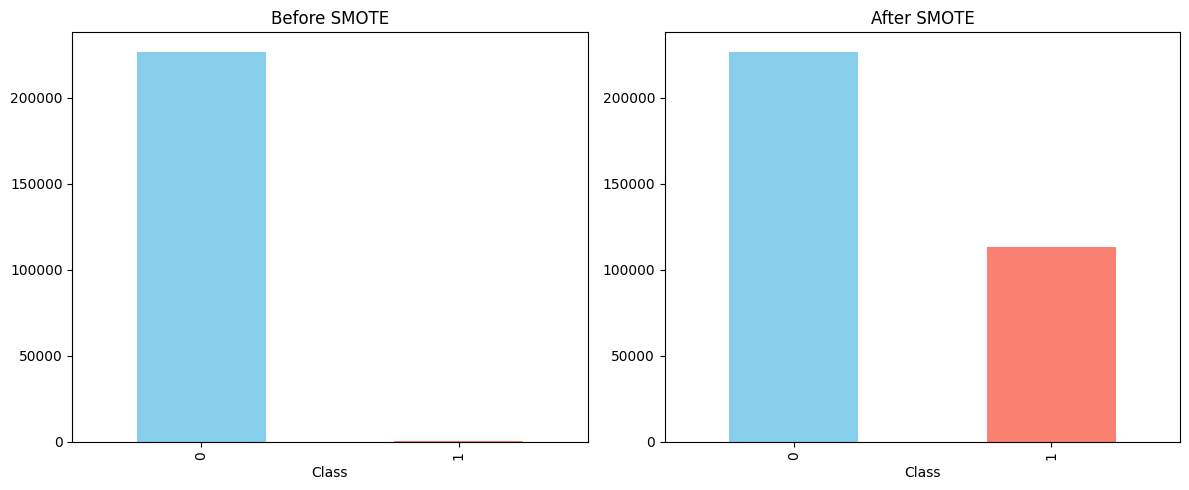

In [11]:
creditcard_preprocessing=FraudDetectionPipeline('../data/processed/processedCreditData.csv', is_fraud=False)
x2_train, y2_train, x2_test, y2_test=creditcard_preprocessing.run()

In [12]:
credit_model= joblib.load("../models/creditcard/XGBoost_final_model.pkl")

In [13]:
model_expected_features = credit_model.n_features_in_
current_data_features = x2_test.shape[1]

print(f"Model expects: {model_expected_features} features")
print(f"x2_test has: {current_data_features} features")


if model_expected_features == current_data_features:
    model_names = set(credit_model.feature_names_in_)
    data_names = set(x2_test.columns)
    print("Missing from data:", model_names - data_names)
    print("Extra in data:", data_names - model_names)


Model expects: 30 features
x2_test has: 30 features
Missing from data: set()
Extra in data: set()


In [14]:
explainer_credit = shap.TreeExplainer(credit_model)
credit_shap_values = explainer_credit(x2_test)

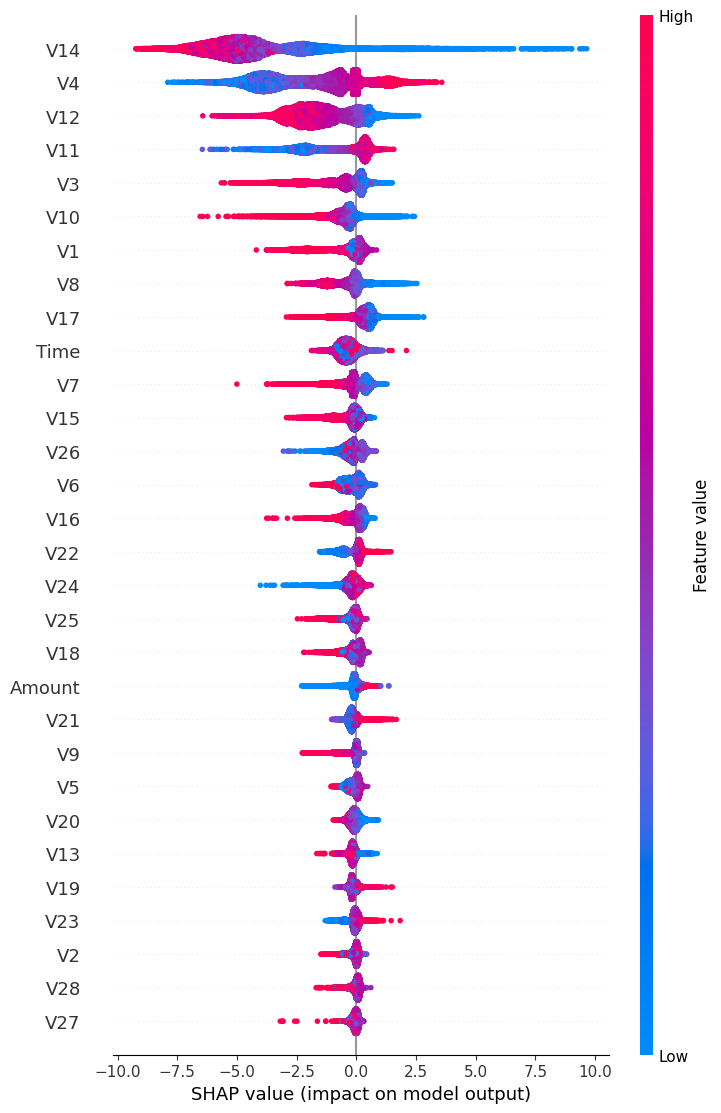

In [15]:
plt.figure(figsize=(10, 15))
shap.plots.beeswarm(credit_shap_values, max_display=30)
plt.show()

In [16]:
preds_cc = credit_model.predict(x2_test)

true_positives_cc = np.where((preds_cc == 1) & (y2_test == 1))[0]
false_positives_cc = np.where((preds_cc == 1) & (y2_test == 0))[0]
false_negatives_cc= np.where((preds_cc == 0) & (y2_test == 1))[0]

print(f"True Positive row indices available: {true_positives_cc[:5]}")
print(f"False Positive row indices available: {false_positives_cc[:5]}")
print(f"False Negative row indices available: {false_negatives_cc[:5]}")

True Positive row indices available: [ 845 1339 2146 4865 5505]
False Positive row indices available: [ 1199  4051 27717 29293 30271]
False Negative row indices available: [ 1784  4480  5187 10087 12142]


In [17]:

shap.initjs()

tp_idx_cc = true_positives_cc[0]
fp_idx_cc = false_positives_cc[0]
fn_idx_cc = false_negatives_cc[0]

print(f"--- Force Plot for True Positive (Row {tp_idx_cc}) ---")
shap.plots.force(credit_shap_values[tp_idx_cc])

print(f"--- Force Plot for False Positive (Row {fp_idx_cc}) ---")
shap.plots.force(credit_shap_values[fp_idx_cc])

print(f"--- Force Plot for False Negative (Row {fn_idx_cc}) ---")
shap.plots.force(credit_shap_values[fn_idx_cc])

--- Force Plot for True Positive (Row 845) ---
--- Force Plot for False Positive (Row 1199) ---
--- Force Plot for False Negative (Row 1784) ---


#### Credit Card Fraud Model - shap analysis - XGBoost

##### 1. SHAP Interpretations (Applied to XGBoost Strategy)

Global Driver Analysis

The selection of the XGBoost model is supported by the achieved Fraud Precision of **0.89** and the low count of **9 False Positives**. The model utilizes the patterns visible in the global summary plot with strict discipline:

* **The Core Fraud Signature (`V14`, `V4`, `V12`):** The model relies on `V14` as the primary filter. A significant drop in the value of `V14` (the blue cluster) serves as an immediate high-risk flag. This signal is paired with elevated values of `V4` and `V11` (the red clusters) to isolate a highly specific profile of fraudulent credit card activity.
* **The Noise Suppression (`Amount`, `Time`):** The variables `Amount` and `Time` exhibit near-zero impact for the vast majority of transactions. The model ignores the variance of normal day-to-day transaction amounts, preventing legitimate large purchases from triggering false alarms. The transaction amount serves only as a minor modifier when the core signature (`V14`/`V4`) indicates a compromised state.

 The Force Plot Logic

The Force Plot demonstrates a risk score driven deeply into the negative safe zone, illustrating the operational efficiency of the system:

* An individual transaction may display minor red flags (such as conflicting values in `V14` and `V4`), but the model requires a coordinated push from multiple features to trigger an active alert.
* The presence of clear trust signals (`V11`, `V17`, `V1`, `V16`) indicates an alignment with normal user behavior, allowing the model to clear the transaction. This strict requirement for a coordination of risk signals restricts false alarms to just **9 instances** across a test set of over 56,000 samples.



 2. Business Implications for XGBoost

Operational Efficiency

The generation of only 9 False Positives out of 56,746 samples minimizes alert fatigue within the in-house team. A flagged transaction carries an **89% probability of representing actual fraud**. This high accuracy allows for the maintenance of a lean operational team, as the need to investigate thousands of false alarms is eliminated.

 The Financial Leakage Profile (The 20% Missed Fraud)

The Fraud Recall of **0.80** indicates the successful prevention of 76 out of 95 fraud attempts. However, **19 actual fraud cases bypassed detection (False Negatives)**. Because conservative decision boundaries are maintained to protect precision, sophisticated anomalies that mask structural deviations in `V14` and `V4` remain undetected. This 20% leakage represents the remaining direct financial exposure from chargeback costs.



##### 3. Business Recommendations 

 A. Automation of the High-Confidence Tier

Given the precision rate of 0.89, manual review is unnecessary for every alert.

* **Action:** Implement an automated action for top-tier scores. If the probability score exceeds a high threshold (e.g., $> 0.85$), the system must bypass human review and automatically block the card or trigger an immediate Multi-Factor Authentication (MFA) challenge.

 B. Mitigation of the 20% Fraud Leakage Gap

To capture the 19 missed fraud cases without increasing the false positive count, behavioral velocity tracking must be introduced in the next model iteration.

* **Action:** Integrate features that evaluate behavioral dynamics over time, such as:
* `card_velocity_1h`: The number of transaction attempts on a card within the hour.
* `declined_attempts_sequence`: A rapid succession of small, failed authorization attempts prior to a main transaction.
* `country_mismatch`: A comparison between the card-issuing country and the transaction IP location.



 C. Establishment of an Upstream Triage Rule

Since `V14` and `V4` dominate the decision logic, the training data should be utilized to define hard boundary thresholds.

* **Action:** Implement an upstream gateway rule prior to model API execution. If an incoming transaction features a catastrophic anomaly in `V14` or `V4`, the system must route the transaction directly to step-up authentication. This reduces the computational load on the real-time model infrastructure and stops blatant fraud at the perimeter.